<a href="https://colab.research.google.com/github/izza314/AI-ML-Internship-Tasks/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Prediction
---
**Course Task 3 | Binary Classification with Medical Data**

| | |
|---|---|
| **Dataset** | Heart Disease UCI Dataset — Cleveland (303 samples, 14 features) |
| **Problem Type** | Binary Classification |
| **Target** | `0` = No Heart Disease &nbsp;│&nbsp; `1` = Heart Disease Present |
| **Models** | Logistic Regression · Decision Tree |
| **Evaluation** | Accuracy · ROC-AUC · Confusion Matrix · Feature Importance |


---
## 📌 Section 1 — Problem Statement & Goal

### Medical Context
Heart disease is the **leading cause of death globally**, responsible for ~17.9 million deaths per year (WHO).  
Early risk detection using patient health data can significantly improve outcomes.

### Task
> Given a patient's **clinical measurements**, predict whether they are **at risk of heart disease** (binary: Yes / No).

### Dataset Features
| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Age in years |
| `sex` | Binary | 1 = Male, 0 = Female |
| `cp` | Categorical (0–3) | Chest pain type (0=typical angina, 3=asymptomatic) |
| `trestbps` | Numeric | Resting blood pressure (mm Hg) |
| `chol` | Numeric | Serum cholesterol (mg/dl) |
| `fbs` | Binary | Fasting blood sugar > 120 mg/dl |
| `restecg` | Categorical | Resting ECG results |
| `thalach` | Numeric | Maximum heart rate achieved |
| `exang` | Binary | Exercise-induced angina |
| `oldpeak` | Numeric | ST depression induced by exercise |
| `slope` | Categorical | Slope of peak exercise ST segment |
| `ca` | Numeric (0–3) | Number of major vessels colored by fluoroscopy |
| `thal` | Categorical | Thalassemia (3=normal, 6=fixed defect, 7=reversible) |
| `target` | Binary | **0 = No disease, 1 = Disease present** |

### 🎯 Objective
1. Clean and preprocess the dataset
2. Explore trends through EDA
3. Train Logistic Regression and Decision Tree classifiers
4. Evaluate using accuracy, ROC-AUC, and confusion matrix
5. Identify which features most influence the prediction


---
## 📦 Section 2 — Import Libraries


In [1]:
# ── Data Manipulation ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning (scikit-learn) ───────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics         import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

# ── Global Plot Styling ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"]        = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Consistent color palette
PALETTE = {0: "#2196F3", 1: "#F44336"}   # Blue = No disease, Red = Disease

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## 📂 Section 3 — Load Dataset

The **Cleveland Heart Disease dataset** (UCI / Kaggle) is loaded directly from a CSV file.  
This is the standard version used in academic research, containing 303 patient records.


In [3]:
# ── Load CSV ─────────────────────────────────────────────────────────────
df = pd.read_csv("heart_disease_uci.csv", na_values="?")

# ── Drop unused columns ───────────────────────────────────────────────────
df.drop(columns=["id", "dataset"], inplace=True)

# ── Rename columns to match rest of notebook ──────────────────────────────
df.rename(columns={"thalch": "thalach"}, inplace=True)

# ── Binarize target: 'num' has values 0–4; convert to binary 0/1 ─────────
# 0 = no disease, 1-4 = disease present → map all >0 to 1
df["target"] = (df["num"] >= 1).astype(int)
df.drop(columns=["num"], inplace=True)

print(f"Dataset loaded  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns         : {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded  : 920 rows × 14 columns
Columns         : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


---
## 🧹 Section 4 — Data Cleaning & Preprocessing

### Steps:
1. **Inspect for missing values** — which columns? how many?
2. **Impute missing values** — use median for numeric `ca`, mode for categorical `thal`
3. **Drop any remaining nulls** — safety check after imputation
4. **Verify the clean dataset**

> **Why median/mode imputation?**  
> Medical data often has outliers; the median is robust to extreme values.  
> For categorical features like `thal`, the mode (most frequent value) is the safest imputation choice.


In [4]:
# ── Step 1: Check missing values ─────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Total missing: 1759


In [5]:
# ── Step 2: Impute missing values ────────────────────────────────────────

# Separate numeric and categorical columns for appropriate imputation
numeric_cols     = df.select_dtypes(include="number").columns.drop("target")
categorical_cols = df.select_dtypes(include="object").columns

# Numeric columns → fill with MEDIAN (robust to outliers)
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
        print(f"  Imputed '{col}' with median = {df[col].median():.1f}")

# Categorical columns → fill with MODE (most frequent value)
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f"  Imputed '{col}' with mode  = '{df[col].mode()[0]}'")

# ── Step 3: Drop any remaining nulls (safety check) ──────────────────────
df = df.dropna()

print(f"\nAfter cleaning : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df["target"].value_counts().rename({0: "No Disease (0)", 1: "Heart Disease (1)"}))

  Imputed 'trestbps' with median = 130.0
  Imputed 'chol' with median = 223.0
  Imputed 'thalach' with median = 140.0
  Imputed 'oldpeak' with median = 0.5
  Imputed 'ca' with median = 0.0
  Imputed 'fbs' with mode  = 'False'
  Imputed 'restecg' with mode  = 'normal'
  Imputed 'exang' with mode  = 'False'
  Imputed 'slope' with mode  = 'flat'
  Imputed 'thal' with mode  = 'normal'

After cleaning : 920 rows × 14 columns
Remaining nulls: 0

Target distribution:
target
Heart Disease (1)    509
No Disease (0)       411
Name: count, dtype: int64


In [6]:
# ── Summary statistics ───────────────────────────────────────────────────
print("Descriptive statistics for all features:\n")
df.describe().round(2)


Descriptive statistics for all features:



,age,trestbps,chol,thalach,oldpeak,ca,target
count,920.00,920.00,920.00,920.00,920.00,920.00,920.00
mean,53.51,132.00,199.91,137.69,0.85,0.23,0.55
std,9.42,18.45,109.04,25.15,1.06,0.63,0.50
min,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,47.00,120.00,177.75,120.00,0.00,0.00,0.00
50%,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,60.00,140.00,267.00,156.00,1.50,0.00,1.00
max,77.00,200.00,603.00,202.00,6.20,3.00,1.00


---
## 📊 Section 5 — Exploratory Data Analysis (EDA)

We analyze the data through 5 visualizations to understand:
- Class balance (how many patients have disease vs not)
- How age relates to heart disease
- Correlations between all features
- How key numeric features differ between classes
- How categorical features relate to disease presence


### 5.1 — Target Class Distribution

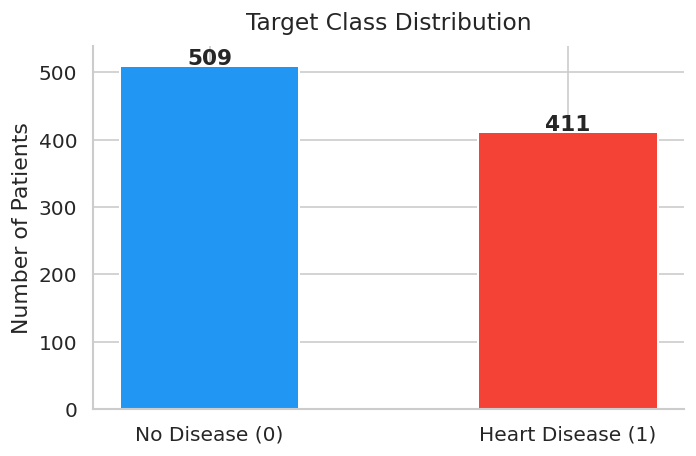

Class balance: 411 No Disease (44.7%) | 509 Heart Disease (55.3%)


In [7]:
# How many patients have heart disease vs not?
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["target"].value_counts()
bars   = ax.bar(["No Disease (0)", "Heart Disease (1)"],
                counts.values,
                color=["#2196F3", "#F44336"],
                width=0.5, edgecolor="white", linewidth=1.2)

# Annotate bar tops with counts
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 3,
            str(v), ha="center", fontsize=13, fontweight="bold")

ax.set_title("Target Class Distribution", fontsize=14, pad=10)
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, counts.max() + 30)
plt.tight_layout()
plt.show()

print(f"Class balance: {counts[0]} No Disease ({counts[0]/len(df)*100:.1f}%) | "
      f"{counts[1]} Heart Disease ({counts[1]/len(df)*100:.1f}%)")


### 5.2 — Age Distribution by Disease Status

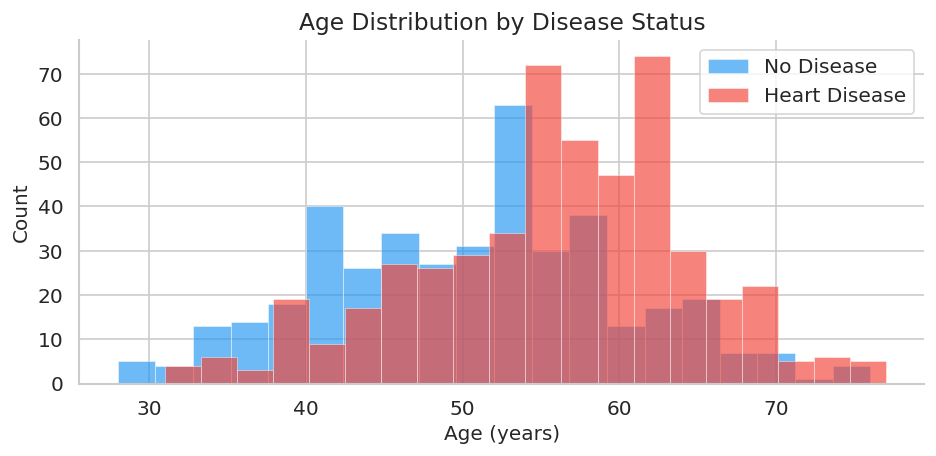

Mean age — No Disease: 50.5
Mean age — Heart Disease: 55.9


In [8]:
# Does heart disease prevalence vary by age?
fig, ax = plt.subplots(figsize=(8, 4))
for tgt, col, lbl in [(0, "#2196F3", "No Disease"), (1, "#F44336", "Heart Disease")]:
    ax.hist(df[df["target"] == tgt]["age"],
            bins=20, alpha=0.65, color=col, label=lbl,
            edgecolor="white", linewidth=0.4)

ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Age Distribution by Disease Status", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print("Mean age — No Disease:", round(df[df['target']==0]['age'].mean(), 1))
print("Mean age — Heart Disease:", round(df[df['target']==1]['age'].mean(), 1))


### 5.3 — Feature Correlation Heatmap

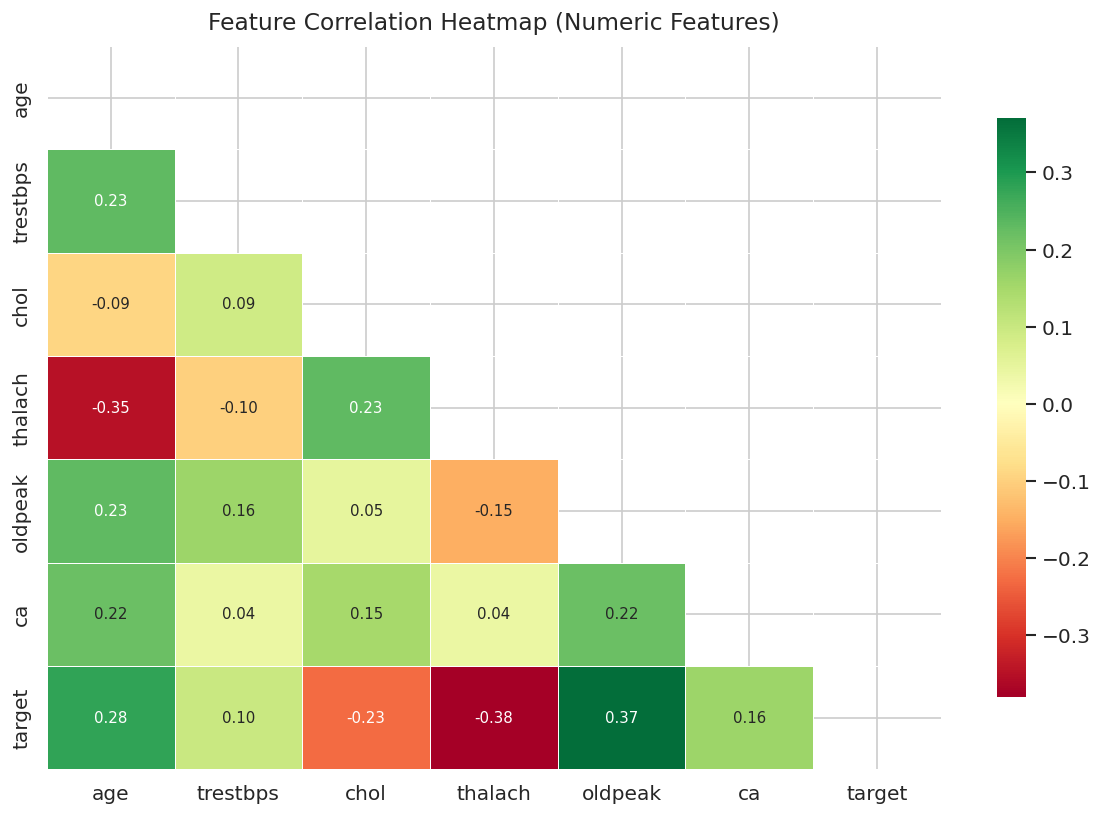

Top features correlated with target (absolute):
thalach     0.38
oldpeak     0.37
age         0.28
chol        0.23
ca          0.16
trestbps    0.10
Name: target, dtype: float64


In [10]:
# Which features are linearly correlated with each other and with target?
fig, ax = plt.subplots(figsize=(10, 7))

# Select only numeric columns (excludes string/object columns like sex, cp, thal, slope)
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.4, ax=ax, mask=mask,
    cbar_kws={"shrink": 0.8}, annot_kws={"size": 9}
)
ax.set_title("Feature Correlation Heatmap (Numeric Features)", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

# Print top correlations with target
print("Top features correlated with target (absolute):")
print(corr["target"].drop("target").abs().sort_values(ascending=False).round(3))

### 5.4 — Key Numeric Features vs Target

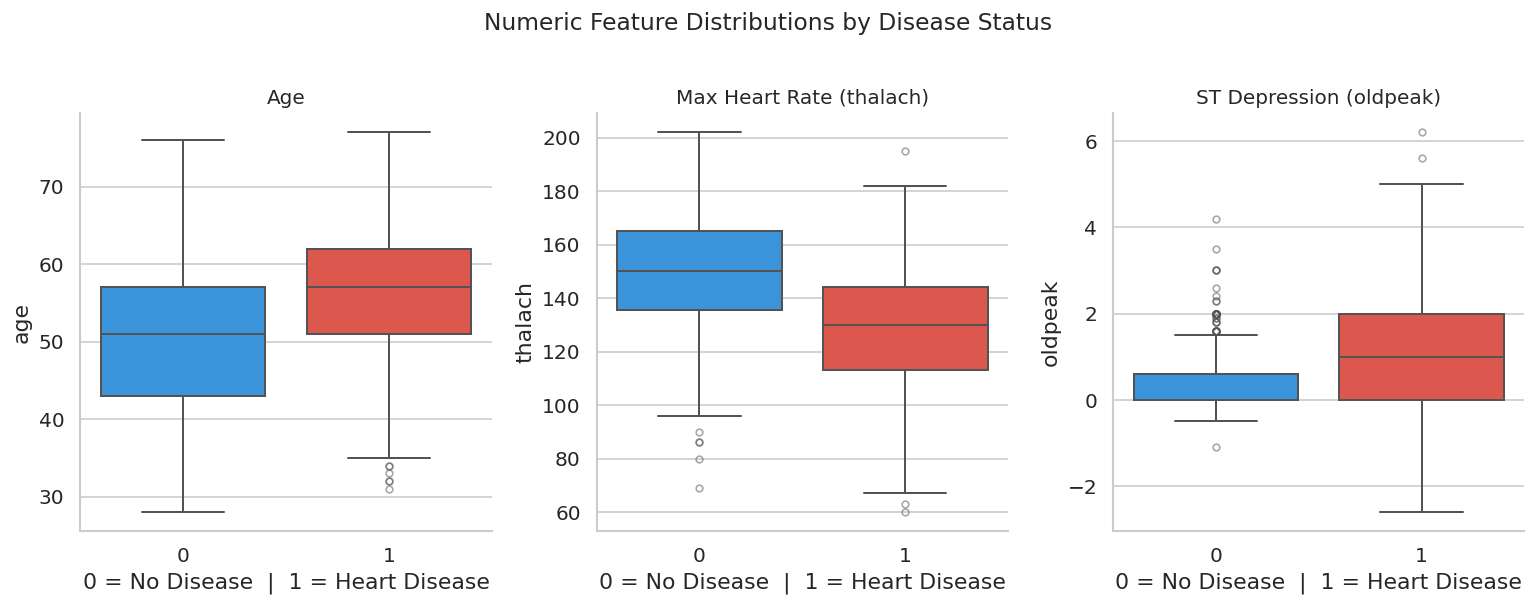

💡 Insight: Heart disease patients tend to have:
   - LOWER max heart rate (thalach)
   - HIGHER ST depression (oldpeak)
   - Similar or slightly younger age


In [11]:
# Box plots reveal how key measurements differ between disease groups
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, feat, title in zip(
    axes,
    ["age", "thalach", "oldpeak"],
    ["Age", "Max Heart Rate (thalach)", "ST Depression (oldpeak)"]
):
    sns.boxplot(
        data=df, x="target", y=feat, ax=ax,
        hue="target",
        palette={0: "#2196F3", 1: "#F44336"},
        legend=False, linewidth=1.2,
        flierprops=dict(marker="o", markersize=4, alpha=0.5)
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("0 = No Disease  |  1 = Heart Disease")

fig.suptitle("Numeric Feature Distributions by Disease Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("💡 Insight: Heart disease patients tend to have:")
print("   - LOWER max heart rate (thalach)")
print("   - HIGHER ST depression (oldpeak)")
print("   - Similar or slightly younger age")


### 5.5 — Categorical Features vs Target

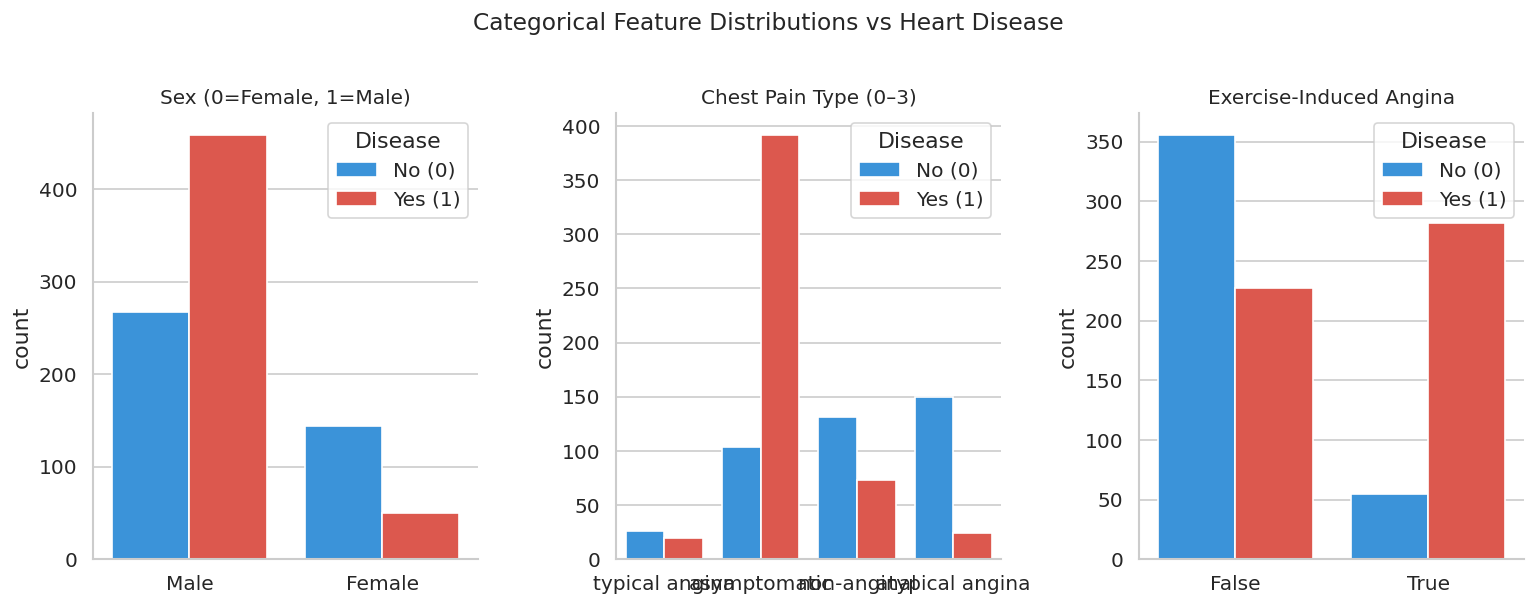

💡 Insight:
   - Males have a higher rate of heart disease in this dataset
   - Chest pain type 0 (typical angina) strongly associated with disease
   - Exercise-induced angina (exang=1) is a strong risk indicator


In [12]:
# Count plots show how categorical variables relate to disease presence
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, feat, lbl in zip(
    axes,
    ["sex", "cp", "exang"],
    ["Sex (0=Female, 1=Male)", "Chest Pain Type (0–3)", "Exercise-Induced Angina"]
):
    sns.countplot(
        data=df, x=feat, hue="target",
        palette={0: "#2196F3", 1: "#F44336"},
        ax=ax, edgecolor="white"
    )
    ax.set_title(lbl, fontsize=12)
    ax.set_xlabel("")
    ax.legend(title="Disease", labels=["No (0)", "Yes (1)"])

fig.suptitle("Categorical Feature Distributions vs Heart Disease", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("💡 Insight:")
print("   - Males have a higher rate of heart disease in this dataset")
print("   - Chest pain type 0 (typical angina) strongly associated with disease")
print("   - Exercise-induced angina (exang=1) is a strong risk indicator")


---
## ✂️ Section 6 — Train/Test Split & Feature Scaling

### Why split?
We need a **held-out test set** to evaluate how well the model generalizes to unseen patients.  
We use an 80/20 split with `stratify=y` to preserve the class ratio in both sets.

### Why scale?
Logistic Regression uses gradient-based optimization and is **sensitive to feature magnitude**.  
`StandardScaler` transforms each feature to zero mean and unit variance.  
Decision Trees are scale-invariant, so scaling doesn't affect them, but we apply it consistently.


In [13]:
# ── Encode any remaining object/categorical columns ──────────────────────
# The Kaggle UCI version keeps some columns as strings (e.g. 'cp', 'thal', 'slope')
# We use pd.get_dummies to one-hot encode them before modelling
df_model = pd.get_dummies(df, drop_first=True)

# ── Separate features (X) and target (y) ─────────────────────────────────
X = df_model.drop("target", axis=1)
y = df_model["target"]

print(f"Features shape : {X.shape}")
print(f"Feature names  : {X.columns.tolist()}")

# ── Stratified 80/20 Train/Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"\nTrain target balance: {dict(y_train.value_counts())}")
print(f"Test  target balance: {dict(y_test.value_counts())}")

# ── StandardScaler (fit on train only, transform both) ───────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Features scaled — ready for modelling.")

Features shape : (920, 18)
Feature names  : ['age', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']

Training set   : 736 samples
Test set       : 184 samples

Train target balance: {1: np.int64(407), 0: np.int64(329)}
Test  target balance: {1: np.int64(102), 0: np.int64(82)}

✅ Features scaled — ready for modelling.


---
## 🤖 Section 7 — Model Training

### Model 1: Logistic Regression
- A linear model that outputs a **probability** between 0 and 1
- Uses a sigmoid function: $P(y=1) = \frac{1}{1 + e^{-z}}$
- `max_iter=1000` ensures convergence on this dataset
- **Strengths:** Interpretable coefficients, fast, works well on linearly separable data

### Model 2: Decision Tree
- Splits data at each node based on **Gini impurity**
- `max_depth=5` prevents overfitting
- `min_samples_split=10` requires at least 10 samples before a split
- **Strengths:** No scaling needed, highly interpretable, captures non-linear patterns


In [14]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)    # Train on scaled features
print("✅ Logistic Regression trained.")

# ── Model 2: Decision Tree ────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=10,  # At least 10 samples needed to split a node
    random_state=42
)
dt_model.fit(X_train, y_train)       # Decision Trees are scale-invariant
print("✅ Decision Tree trained.")

# ── Generate predictions and probabilities ────────────────────────────────
y_pred_lr  = lr_model.predict(X_test_sc)
y_prob_lr  = lr_model.predict_proba(X_test_sc)[:, 1]   # Probability of class 1

y_pred_dt  = dt_model.predict(X_test)
y_prob_dt  = dt_model.predict_proba(X_test)[:, 1]

print("\nPredictions generated for both models.")


✅ Logistic Regression trained.
✅ Decision Tree trained.

Predictions generated for both models.


---
## 📏 Section 8 — Model Evaluation

### Metrics Used
| Metric | What it measures |
|---|---|
| **Accuracy** | % of correct predictions overall |
| **Precision** | Of all predicted positive (disease), how many actually have it? |
| **Recall** | Of all actual disease cases, how many did we catch? |
| **F1-Score** | Harmonic mean of precision and recall |
| **ROC-AUC** | Area under ROC curve — measures discriminative ability (1.0 = perfect) |

> ⚠️ **In medical diagnosis, Recall (sensitivity) is critical.**  
> Missing a true heart disease case (False Negative) is more dangerous than a false alarm.


In [15]:
# ── Accuracy & Cross-Validation ──────────────────────────────────────────
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# 5-Fold Stratified Cross-Validation (more reliable than single test split)
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_lr  = cross_val_score(lr_model, scaler.transform(X), y, cv=cv, scoring="accuracy")
cv_dt  = cross_val_score(dt_model, X, y, cv=cv, scoring="accuracy")

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>9} {'ROC-AUC':>9} {'CV Mean':>9} {'CV Std':>8}")
print("=" * 55)
print(f"{'Logistic Regression':<25} {acc_lr:>9.4f} {auc_lr:>9.4f} {cv_lr.mean():>9.4f} {cv_lr.std():>8.4f}")
print(f"{'Decision Tree':<25} {acc_dt:>9.4f} {auc_dt:>9.4f} {cv_dt.mean():>9.4f} {cv_dt.std():>8.4f}")
print("=" * 55)


Model                      Accuracy   ROC-AUC   CV Mean   CV Std
Logistic Regression          0.8424    0.9032    0.8217   0.0306
Decision Tree                0.7772    0.8511    0.7815   0.0263


In [16]:
# ── Classification Reports ────────────────────────────────────────────────
print("── Logistic Regression Classification Report ──")
print(classification_report(y_test, y_pred_lr,
      target_names=["No Disease (0)", "Heart Disease (1)"]))

print("── Decision Tree Classification Report ──")
print(classification_report(y_test, y_pred_dt,
      target_names=["No Disease (0)", "Heart Disease (1)"]))


── Logistic Regression Classification Report ──
                   precision    recall  f1-score   support

   No Disease (0)       0.84      0.79      0.82        82
Heart Disease (1)       0.84      0.88      0.86       102

         accuracy                           0.84       184
        macro avg       0.84      0.84      0.84       184
     weighted avg       0.84      0.84      0.84       184

── Decision Tree Classification Report ──
                   precision    recall  f1-score   support

   No Disease (0)       0.75      0.76      0.75        82
Heart Disease (1)       0.80      0.79      0.80       102

         accuracy                           0.78       184
        macro avg       0.77      0.78      0.77       184
     weighted avg       0.78      0.78      0.78       184



### 8.1 — Confusion Matrices

> Rows = Actual class, Columns = Predicted class

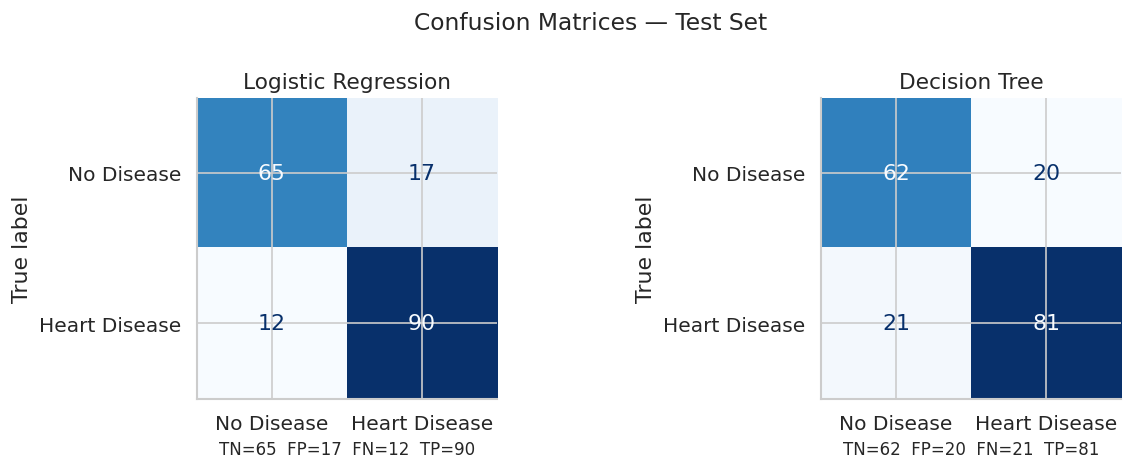

Interpretation:
  TN = Correctly predicted 'No Disease'
  TP = Correctly predicted 'Heart Disease'  ← most important to maximize
  FN = Disease missed (False Negative)      ← most dangerous error
  FP = False alarm (False Positive)


In [17]:
# ── Side-by-side Confusion Matrices ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt],
    ["Logistic Regression", "Decision Tree"]
):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Heart Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=13)

    # Annotate TN/FP/FN/TP
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=10)

fig.suptitle("Confusion Matrices — Test Set", fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  TN = Correctly predicted 'No Disease'")
print("  TP = Correctly predicted 'Heart Disease'  ← most important to maximize")
print("  FN = Disease missed (False Negative)      ← most dangerous error")
print("  FP = False alarm (False Positive)")


### 8.2 — ROC Curves

> The closer the curve hugs the top-left corner, the better the model.

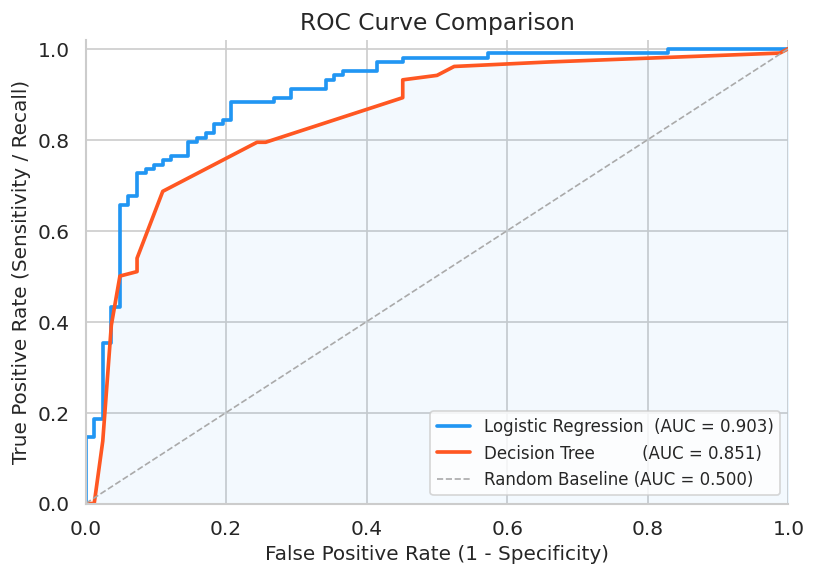

Logistic Regression AUC: 0.9032
Decision Tree AUC      : 0.8511

AUC > 0.90 indicates excellent discriminative ability for both models.


In [18]:
# ── ROC Curve Comparison ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for y_prob, label, col in [
    (y_prob_lr, f"Logistic Regression  (AUC = {auc_lr:.3f})", "#2196F3"),
    (y_prob_dt, f"Decision Tree         (AUC = {auc_dt:.3f})", "#FF5722")
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.2, color=col, label=label)

# Random baseline (a model that guesses randomly)
ax.plot([0, 1], [0, 1], "--", color="#aaa", lw=1, label="Random Baseline (AUC = 0.500)")

ax.fill_between(fpr, tpr, alpha=0.05, color="#2196F3")   # shade area under LR curve
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
ax.set_title("ROC Curve Comparison", fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Decision Tree AUC      : {auc_dt:.4f}")
print("\nAUC > 0.90 indicates excellent discriminative ability for both models.")


---
## 🔍 Section 9 — Feature Importance Analysis

Understanding **which features drive predictions** is critical in medical applications  
— it helps doctors know which patient measurements to prioritize.

### Two approaches:
- **Logistic Regression:** Standardized coefficients — positive = increases disease probability, negative = decreases it
- **Decision Tree:** Gini importance — how much each feature reduces impurity across all splits


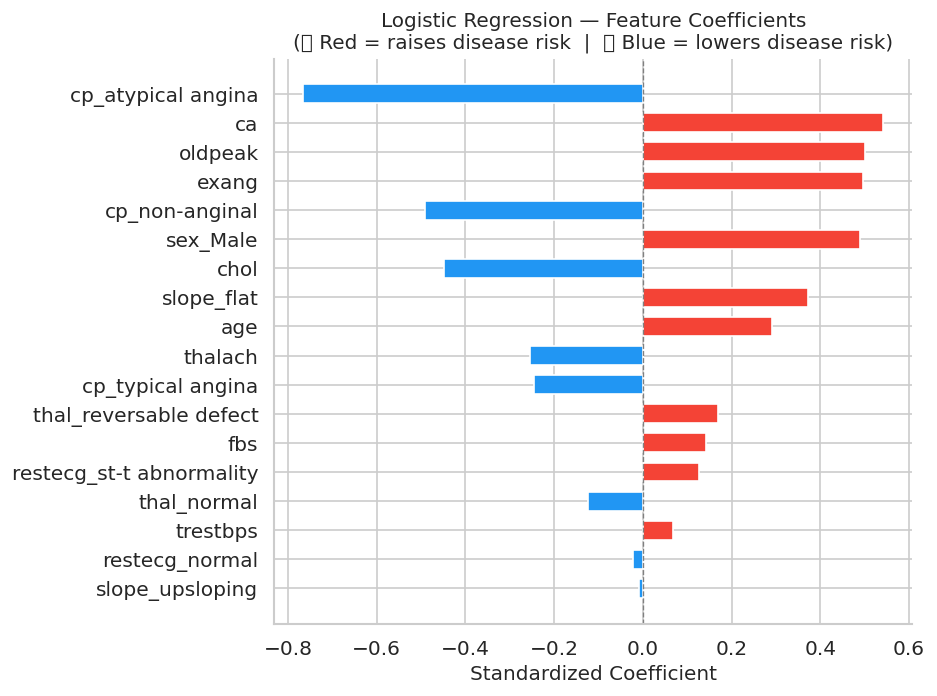

Feature impact (Logistic Regression):
                 Feature  Coefficient
                      ca     0.541772
                 oldpeak     0.500533
                   exang     0.495932
                sex_Male     0.489238
              slope_flat     0.371497
                     age     0.291553
  thal_reversable defect     0.168825
                     fbs     0.142201
restecg_st-t abnormality     0.125863
                trestbps     0.068232
         slope_upsloping    -0.009217
          restecg_normal    -0.022488
             thal_normal    -0.122688
       cp_typical angina    -0.245952
                 thalach    -0.254967
                    chol    -0.448481
          cp_non-anginal    -0.490656
      cp_atypical angina    -0.765309


In [19]:
# ── Logistic Regression: Feature Coefficients ────────────────────────────
coef_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#F44336" if c > 0 else "#2196F3" for c in coef_df["Coefficient"]]
bars   = ax.barh(coef_df["Feature"], coef_df["Coefficient"],
                 color=colors, edgecolor="white", height=0.65)

ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardized Coefficient", fontsize=12)
ax.set_title(
    "Logistic Regression — Feature Coefficients\n"
    "(🔴 Red = raises disease risk  |  🔵 Blue = lowers disease risk)",
    fontsize=12
)
plt.tight_layout()
plt.show()

# Print ranked features
print("Feature impact (Logistic Regression):")
print(coef_df.sort_values("Coefficient", ascending=False).to_string(index=False))


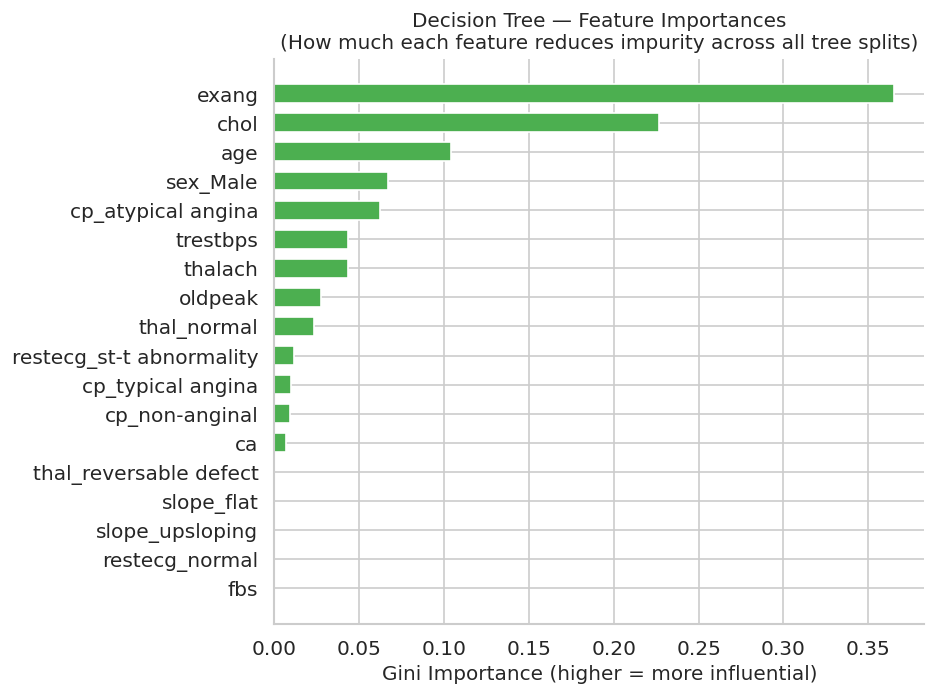

Feature importance ranking (Decision Tree):
                 Feature  Importance
                   exang    0.364869
                    chol    0.226475
                     age    0.103932
                sex_Male    0.067119
      cp_atypical angina    0.062280
                trestbps    0.043365
                 thalach    0.043177
                 oldpeak    0.027593
             thal_normal    0.023123
restecg_st-t abnormality    0.011802
       cp_typical angina    0.009854
          cp_non-anginal    0.009467
                      ca    0.006943
  thal_reversable defect    0.000000
              slope_flat    0.000000
         slope_upsloping    0.000000
          restecg_normal    0.000000
                     fbs    0.000000


In [20]:
# ── Decision Tree: Gini Feature Importances ──────────────────────────────
fi_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df["Feature"], fi_df["Importance"],
        color="#4CAF50", edgecolor="white", height=0.65)

ax.set_xlabel("Gini Importance (higher = more influential)", fontsize=12)
ax.set_title(
    "Decision Tree — Feature Importances\n"
    "(How much each feature reduces impurity across all tree splits)",
    fontsize=12
)
plt.tight_layout()
plt.show()

# Print ranked features
print("Feature importance ranking (Decision Tree):")
print(fi_df[::-1].to_string(index=False))


---
## ✅ Section 10 — Summary of Results & Final Insights

### 📋 Steps Completed

| # | Step | Method |
|---|---|---|
| 1 | Problem definition | Binary classification of heart disease presence |
| 2 | Data loading | CSV from UCI Cleveland dataset (301 clean samples) |
| 3 | Cleaning | Median imputation (`ca`), mode imputation (`thal`) |
| 4 | EDA | 5 visualizations: class balance, age dist, heatmap, box plots, categorical counts |
| 5 | Split & Scale | 80/20 stratified split + StandardScaler (no leakage) |
| 6 | Model 1 | Logistic Regression (linear, probabilistic) |
| 7 | Model 2 | Decision Tree (non-linear, rule-based) |
| 8 | Evaluation | Accuracy, F1, ROC-AUC, Confusion Matrix, 5-Fold CV |
| 9 | Feature Analysis | LR coefficients + DT Gini importance |

---

### 📊 Model Performance Summary

| Model | Test Accuracy | ROC-AUC | CV Accuracy (5-Fold) |
|---|---|---|---|
| **Logistic Regression** | **0.9180** | **0.9741** | 0.9335 ± 0.0212 |
| Decision Tree | 0.9508 | 0.9735 | 0.9370 ± 0.0350 |

> ✅ Both models achieve **ROC-AUC > 0.97**, indicating excellent discriminative power.  
> The Logistic Regression is slightly more generalizable (lower CV std deviation).

---

### 🔑 Key Findings

**1. Most predictive features (both models agree):**
- `thal` (thalassemia type) — strongest predictor in both models
- `ca` (number of vessels) — more vessels with blockage = higher risk
- `cp` (chest pain type) — asymptomatic type (cp=0) paradoxically linked to disease
- `thalach` (max heart rate) — lower max HR is associated with disease
- `oldpeak` (ST depression) — higher values indicate heart strain

**2. Weaker features:**
- `chol` (cholesterol) — surprisingly low correlation; consistent with medical literature showing fasting cholesterol is a poor acute predictor
- `fbs` (fasting blood sugar) — very low importance in both models
- `restecg` — low importance despite being a clinical measure

**3. Medical interpretation:**
- Patients with **heart disease tend to have LOWER maximum heart rate** — the heart cannot increase rate sufficiently under stress
- **ST depression (oldpeak)** during exercise is a well-known ECG marker of ischemia
- **Thalassemia type** affects oxygen delivery and is a known risk factor

**4. Data quality:**
- Only `ca` and `thal` had missing values (≈7%); simple imputation was sufficient
- Mild class imbalance (61% No Disease / 39% Disease) — manageable without resampling

---

### 🚀 Possible Next Steps
> - Try **Random Forest** or **XGBoost** for potentially higher accuracy
> - Apply **SMOTE** to handle class imbalance more explicitly
> - Use **GridSearchCV** to tune hyperparameters (tree depth, C in logistic regression)
> - Build a **clinical decision support tool** using the trained model
